In [8]:
from __future__ import annotations

import sqlite3
import sys
from pathlib import Path

from IPython.display import display

MONTH_DAYS = (31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31)
POSITIONS = (
    "GK", "RB", "CB", "LB", "DM", "CM", "RM", "LM", "AM", "RW", "LW", "CF", "ST",
)
AVAILABILITY = ("Available", "Injured", "Suspended")

HERE = Path.cwd().resolve()

In [9]:
def date_from_day(total_days: int) -> str:
    year = total_days // 365 + 1
    doy = total_days % 365 + 1
    month = 1
    remaining = doy
    for days in MONTH_DAYS:
        if remaining <= days:
            break
        remaining -= days
        month += 1
    return f"{year:04d}-{month:02d}-{remaining:02d}"


def fmt_ms(ms: float) -> str:
    if ms != ms:
        return "-"
    if ms < 1000:
        return f"{ms:.0f}ms"
    if ms < 60_000:
        return f"{ms / 1000:.2f}s"
    h, rem = divmod(int(ms) / 1000, 3600)
    m, s = divmod(rem, 60)
    return f"{int(h)}:{int(m):02d}:{int(s):02d}"


def money(n) -> str:
    if n is None:
        return "-"
    return f"{int(n):,}"


def heading(title: str) -> None:
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)


def show(df, title: str, n: int | None = None) -> None:
    heading(title)
    if df is None or df.empty:
        print("(none)")
        return
    view = df.head(n) if n else df
    display(view.reset_index(drop=True))
    if n and len(df) > n:
        print(f"... {len(df) - n} more")

In [10]:
def load_profile(csv_path: Path):
    import pandas as pd

    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=df["day"])
    )
    df["idle"] = df["matches"] == 0
    df["week"] = (df["simDay"] - 1) // 7 + 1
    df["advanceSec"] = df["advanceMs"] / 1000.0
    df["weekMs"] = df["advanceMs"].rolling(7, min_periods=1).sum()
    df["calendarDay"] = (
        (df["year"] - 1) * 365
        + df["day"]
        - 1
        + df["month"].map(lambda m: sum(MONTH_DAYS[: m - 1]))
    )
    doy = df["calendarDay"] % 365 + 1
    df["transferTick"] = (df["calendarDay"] % 7 == 0) & (
        ((doy >= 1) & (doy <= 31)) | ((doy >= 182) & (doy <= 243))
    )
    return df


def print_profile(df) -> None:
    heading("Performance (AdvanceDays)")
    idle = df[df["idle"]]
    busy = df[~df["idle"]]
    print(f"Days:            {len(df)}")
    print(f"Matches:         {int(df['matches'].sum())}")
    print(f"Wall advance:    {fmt_ms(df['advanceMs'].sum())}")
    print(f"Mean / day:      {fmt_ms(df['advanceMs'].mean())}")
    print(f"p50 / p95 / max: {fmt_ms(df['advanceMs'].median())}  "
          f"{fmt_ms(df['advanceMs'].quantile(0.95))}  {fmt_ms(df['advanceMs'].max())}")
    if len(idle):
        print(f"Idle days:       n={len(idle)}  mean {fmt_ms(idle['advanceMs'].mean())}  "
              f"max {fmt_ms(idle['advanceMs'].max())}")
    if len(busy):
        print(f"Matchdays:       n={len(busy)}  mean {fmt_ms(busy['advanceMs'].mean())}  "
              f"max {fmt_ms(busy['advanceMs'].max())}  "
              f"{fmt_ms(busy['advanceMs'].sum() / busy['matches'].sum())}/match")
    weeks = df.groupby("week")["advanceMs"].sum()
    print(f"Weeks:           n={len(weeks)}  mean {fmt_ms(weeks.mean())}  max {fmt_ms(weeks.max())}")
    months = df.groupby(["year", "month"])["advanceMs"].agg(["sum", "count", "max"])
    print("Months:")
    for (y, m), row in months.iterrows():
        print(f"  {int(y):04d}-{int(m):02d}  {int(row['count']):3d} days  "
              f"{fmt_ms(row['sum'])}  peak {fmt_ms(row['max'])}")
    ticks = df[df["transferTick"]]
    if len(ticks):
        print(f"Open-window transfer ticks (day%7==0): n={len(ticks)}  "
              f"mean {fmt_ms(ticks['advanceMs'].mean())}  max {fmt_ms(ticks['advanceMs'].max())}")
    worst = df.nlargest(10, "advanceMs")[
        ["simDay", "date", "matches", "advanceMs", "workingSetMb", "transferTick"]
    ]
    show(worst, "Worst hitches")
    print(f"RSS:  {int(df['workingSetMb'].min())}–{int(df['workingSetMb'].max())} MB   "
          f"heap {int(df['gcHeapMb'].min())}–{int(df['gcHeapMb'].max())} MB")

def plot_profile(df, out_dir: Path, show_plots: bool) -> None:
    import matplotlib.pyplot as plt

    out_dir.mkdir(parents=True, exist_ok=True)
    ticks = df[df["transferTick"]]

    fig, axes = plt.subplots(3, 2, figsize=(14, 11), constrained_layout=True)
    ax = axes[0, 0]
    ax.plot(df["simDay"], df["advanceSec"], lw=0.9, color="#1f77b4")
    if len(ticks):
        ax.scatter(ticks["simDay"], ticks["advanceSec"], s=18, c="#d62728", zorder=3, label="transfer tick")
        ax.legend(loc="upper right")
    ax.set_title("Advance time / day")
    ax.set_ylabel("seconds")
    ax.set_xlabel("sim day")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["simDay"], df["weekMs"] / 1000, color="#ff7f0e")
    ax.set_title("Rolling 7-day advance")
    ax.set_ylabel("seconds / week")
    ax.set_xlabel("sim day")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    colors = ["#cccccc" if idle else "#2ca02c" for idle in df["idle"]]
    ax.bar(df["simDay"], df["matches"], color=colors, width=1.0)
    ax.set_title("Matches / day")
    ax.set_xlabel("sim day")
    ax.grid(True, axis="y", alpha=0.3)

    ax = axes[1, 1]
    busy = df.loc[~df["idle"]].dropna(subset=["msPerMatch"])
    ax.scatter(busy["simDay"], busy["msPerMatch"], s=12, alpha=0.7, c="#9467bd")
    ax.set_title("ms / match on matchdays")
    ax.set_xlabel("sim day")
    ax.grid(True, alpha=0.3)

    ax = axes[2, 0]
    ax.plot(df["simDay"], df["workingSetMb"], label="RSS")
    ax.plot(df["simDay"], df["gcHeapMb"], label="GC heap")
    ax.set_title("Memory")
    ax.set_ylabel("MB")
    ax.set_xlabel("sim day")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    ax.plot(df["simDay"], df["gen0"], label="gen0")
    ax.plot(df["simDay"], df["gen1"], label="gen1")
    ax.plot(df["simDay"], df["gen2"], label="gen2")
    ax.set_title("GC collection counts (cumulative)")
    ax.set_xlabel("sim day")
    ax.legend()
    ax.grid(True, alpha=0.3)

    path = out_dir / "profile-days.png"
    fig.savefig(path, dpi=120)
    print(f"Saved {path}")

    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes2[0].hist(df["advanceMs"], bins=40, color="#1f77b4", edgecolor="white")
    axes2[0].set_title("Day hitch distribution (ms)")
    axes2[0].set_xlabel("advanceMs")
    axes2[0].grid(True, axis="y", alpha=0.3)

    monthly = df.groupby(["year", "month"])["advanceMs"].sum().reset_index()
    monthly["label"] = monthly.apply(lambda r: f"{int(r.year)}-{int(r.month):02d}", axis=1)
    axes2[1].bar(monthly["label"], monthly["advanceMs"] / 1000, color="#8c564b")
    axes2[1].set_title("Advance time by calendar month")
    axes2[1].set_ylabel("seconds")
    axes2[1].tick_params(axis="x", rotation=45)
    axes2[1].grid(True, axis="y", alpha=0.3)

    path = out_dir / "profile-dist.png"
    fig2.savefig(path, dpi=120)
    print(f"Saved {path}")

    if show_plots:
        plt.show()
    else:
        plt.close("all")

In [11]:
def q(con, sql: str, params=()):
    import pandas as pd

    return pd.read_sql_query(sql, con, params=params)


def dump_world(con) -> None:
    meta = q(con, "SELECT Seed, SchemaVersion, CurrentDay, CreatedUtcTicks FROM PlaythroughMetadata LIMIT 1")
    heading("World")
    if meta.empty:
        print("No PlaythroughMetadata.")
        return
    day = int(meta.CurrentDay.iloc[0])
    print(f"Seed:          {int(meta.Seed.iloc[0])}")
    print(f"Schema:        {int(meta.SchemaVersion.iloc[0])}")
    print(f"Current day:   {day}  ({date_from_day(day)})")

    display(q(con, """
        SELECT l.Name league, COUNT(t.Id) clubs, ls.WinnerPrize prize,
               ls.StartMonth start_mo, ls.EndMonth end_mo
        FROM Leagues l
        JOIN Teams t ON t.LeagueId = l.Id
        JOIN LeagueSettings ls ON ls.LeagueId = l.Id
        GROUP BY l.Id
        ORDER BY l.Name
    """))

    counts = q(con, """
        SELECT
          (SELECT COUNT(*) FROM Leagues) leagues,
          (SELECT COUNT(*) FROM Teams) clubs,
          (SELECT COUNT(*) FROM Footballers) players,
          (SELECT COUNT(*) FROM Footballers WHERE TeamId IS NULL) free_players,
          (SELECT COUNT(*) FROM Coaches) coaches,
          (SELECT COUNT(*) FROM Coaches WHERE TeamId IS NULL) free_coaches,
          (SELECT COUNT(*) FROM Fixtures) fixtures,
          (SELECT COUNT(*) FROM Fixtures WHERE IsPlayed=1) played,
          (SELECT COUNT(*) FROM SeasonHistory) finished_seasons
    """)
    print()
    display(counts)

    avail = q(con, """
        SELECT Availability, COUNT(*) n,
               SUM(CASE WHEN InjuryDaysRemaining>0 THEN 1 ELSE 0 END) injured_days,
               SUM(CASE WHEN SuspensionMatchesRemaining>0 THEN 1 ELSE 0 END) suspended
        FROM FootballerState GROUP BY Availability
    """)
    if not avail.empty:
        avail["status"] = avail["Availability"].map(lambda i: AVAILABILITY[i] if i < 3 else i)
        show(avail[["status", "n", "injured_days", "suspended"]], "Availability")

    show(q(con, """
        SELECT h.SeasonId, l.Name league, t.Name winner, h.Prize, h.CompletedDay
        FROM SeasonHistory h
        JOIN LeagueSeasons s ON s.Id = h.SeasonId
        JOIN Leagues l ON l.Id = s.LeagueId
        JOIN Teams t ON t.Id = h.WinnerTeamId
        ORDER BY h.CompletedDay, l.Name
    """), "Completed seasons")

    seasons = q(con, """
        SELECT s.Id, l.Name league, s.Name season, s.StartDay, s.EndDay,
               CASE WHEN h.SeasonId IS NULL THEN 'in progress' ELSE 'complete' END status
        FROM LeagueSeasons s
        JOIN Leagues l ON l.Id = s.LeagueId
        LEFT JOIN SeasonHistory h ON h.SeasonId = s.Id
        ORDER BY s.StartDay, l.Name
    """)
    show(seasons, "Seasons")

    standings = q(con, """
        SELECT s.Id season_id, l.Name league, s.Name season,
               CASE WHEN h.SeasonId IS NULL THEN 'in progress' ELSE 'complete' END status,
               t.Name team, st.Played, st.Won, st.Drawn, st.Lost,
               st.GoalsFor gf, st.GoalsAgainst ga, (st.GoalsFor-st.GoalsAgainst) gd, st.Points
        FROM SeasonStandings st
        JOIN LeagueSeasons s ON s.Id = st.SeasonId
        JOIN Leagues l ON l.Id = s.LeagueId
        JOIN Teams t ON t.Id = st.TeamId
        LEFT JOIN SeasonHistory h ON h.SeasonId = s.Id
        ORDER BY s.StartDay, l.Name, st.Points DESC, gd DESC, st.GoalsFor DESC, t.Name
    """)
    if standings.empty:
        heading("Tables")
        print("(none)")
    else:
        for (sid, league, season, status), table in standings.groupby(
            ["season_id", "league", "season", "status"], sort=False
        ):
            show(
                table.drop(columns=["season_id", "league", "season", "status"]).reset_index(drop=True),
                f"{league} — {season} ({status})",
            )

    players = q(con, """
        SELECT f.Name player, t.Name team, l.Name league, f.Position, f.Age, f.Nationality,
               COALESCE(r.Overall, 0) overall, COALESCE(tot.Appearances,0) apps,
               COALESCE(tot.Starts,0) starts, COALESCE(tot.Minutes,0) minutes,
               COALESCE(tot.Goals,0) goals, COALESCE(tot.Assists,0) assists,
               COALESCE(tot.YellowCards,0) yc, COALESCE(tot.RedCards,0) rc,
               s.Morale, s.Fitness, s.Fatigue, s.RecentMatchRating rating,
               COALESCE(d.Form,50) form, s.Availability
        FROM Footballers f
        LEFT JOIN Teams t ON t.Id = f.TeamId
        LEFT JOIN Leagues l ON l.Id = t.LeagueId
        LEFT JOIN PlayerRatings r ON r.FootballerId = f.Id
        LEFT JOIN PlayerTotals tot ON tot.FootballerId = f.Id
        LEFT JOIN FootballerState s ON s.FootballerId = f.Id
        LEFT JOIN DevelopmentData d ON d.FootballerId = f.Id
    """)
    if not players.empty:
        players["pos"] = players["Position"].map(lambda i: POSITIONS[i] if i < len(POSITIONS) else i)
        players["status"] = players["Availability"].map(lambda i: AVAILABILITY[i] if i < 3 else i)

        show(
            players.nlargest(25, "overall")[
                ["player", "team", "league", "pos", "Age", "overall", "apps", "goals", "assists", "form"]
            ],
            "Best players (overall)",
            25,
        )
        show(
            players.nlargest(25, "goals")[
                ["player", "team", "league", "pos", "apps", "minutes", "goals", "assists", "overall"]
            ],
            "Top scorers (career totals in this save)",
            25,
        )
        show(
            players.nlargest(25, "assists")[
                ["player", "team", "league", "pos", "apps", "assists", "goals", "overall"]
            ],
            "Top assists",
            25,
        )
        rated = q(con, """
            SELECT f.Name player, t.Name team, COUNT(*) games,
                   ROUND(AVG(p.Rating), 1) avg_rating, SUM(p.Goals) goals, SUM(p.Assists) assists,
                   SUM(p.MinutesPlayed) minutes
            FROM FootballerMatchPerformances p
            JOIN Footballers f ON f.Id = p.FootballerId
            LEFT JOIN Teams t ON t.Id = f.TeamId
            WHERE p.Rating IS NOT NULL
            GROUP BY p.FootballerId
            HAVING games >= 8
            ORDER BY avg_rating DESC, games DESC
            LIMIT 25
        """)
        show(rated, "Highest average match rating (min 8 games)")

        show(
            players[players["status"] != "Available"][
                ["player", "team", "pos", "status", "overall"]
            ].head(30),
            "Unavailable players",
        )

    show(q(con, """
        SELECT l.Name league, home.Name home, away.Name away,
               f.HomeGoals || '-' || f.AwayGoals score, f.Matchday, f.ScheduledDay
        FROM Fixtures f
        JOIN Teams home ON home.Id = f.HomeTeamId
        JOIN Teams away ON away.Id = f.AwayTeamId
        JOIN Leagues l ON l.Id = f.LeagueId
        WHERE f.IsPlayed = 1
        ORDER BY ABS(f.HomeGoals - f.AwayGoals) DESC, (f.HomeGoals + f.AwayGoals) DESC
        LIMIT 20
    """), "Biggest results")

    show(q(con, """
        SELECT t.Name club, l.Name league, rt.Balance cash, cf.DailyIncome, cf.WageBudget,
               rt.Morale, rt.Form, rt.FanSupport,
               (SELECT COUNT(*) FROM Footballers p WHERE p.TeamId = t.Id) squad,
               (SELECT COALESCE(SUM(c.DailyWage),0) FROM Contracts c WHERE c.TeamId = t.Id) wages
        FROM Teams t
        JOIN Leagues l ON l.Id = t.LeagueId
        JOIN TeamRuntime rt ON rt.TeamId = t.Id
        JOIN ClubFinances cf ON cf.TeamId = t.Id
        ORDER BY rt.Balance DESC
        LIMIT 20
    """), "Richest clubs")

    history = q(con, """
        SELECT Type, COUNT(*) n, SUM(Amount) amount
        FROM WorldHistory
        GROUP BY Type
        ORDER BY n DESC
    """)
    show(history, "World history by type")

    show(q(con, """
        SELECT h.Day, h.Type, COALESCE(f.Name, c.Name) person, frm.Name "from", too.Name "to", h.Amount
        FROM WorldHistory h
        LEFT JOIN Footballers f ON f.Id = h.PersonId
        LEFT JOIN Coaches c ON c.Id = h.PersonId
        LEFT JOIN Teams frm ON frm.Id = h.FromTeamId
        LEFT JOIN Teams too ON too.Id = h.ToTeamId
        WHERE h.Type IN ('player-transfer','coach-transfer','release','renewal')
        ORDER BY h.Day DESC, h.Id DESC
        LIMIT 30
    """), "Recent market events")

In [12]:
CURRENT_DB = HERE / "bin" / "Debug" / "net8.0" / "ten-leagues.db"
CURRENT_CSV = CURRENT_DB.with_suffix(".profile.csv")
CURRENT_OUT = CURRENT_CSV.with_name(CURRENT_CSV.stem + "-report")

db = CURRENT_DB.resolve()
csv_path = CURRENT_CSV.resolve()
out_dir = CURRENT_OUT.resolve()

try:
    import pandas as pd
except ImportError:
    print("Install pandas and matplotlib:  pip install pandas matplotlib", file=sys.stderr)
    raise

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 40)

print(f"HERE: {HERE}")
print(f"CSV:  {csv_path}  ({'ok' if csv_path.is_file() else 'missing'})")
print(f"DB:   {db}  ({'ok' if db.is_file() else 'missing'})")
print(f"OUT:  {out_dir}")

HERE: D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual
CSV:  D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual\bin\Debug\net8.0\ten-leagues.profile.csv  (ok)
DB:   D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual\bin\Debug\net8.0\ten-leagues.db  (ok)
OUT:  D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual\bin\Debug\net8.0\ten-leagues.profile-report



Performance (AdvanceDays)
Days:            1002
Matches:         10584
Wall advance:    0:03:22
Mean / day:      202ms
p50 / p95 / max: 135ms  510ms  1.35s
Idle days:       n=501  mean 113ms  max 879ms
Matchdays:       n=501  mean 291ms  max 1.35s  14ms/match
Weeks:           n=144  mean 1.41s  max 2.88s
Months:
  2026-08   31 days  8.72s  peak 868ms
  2026-09   30 days  5.48s  peak 511ms
  2026-10   31 days  5.98s  peak 502ms
  2026-11   30 days  5.99s  peak 497ms
  2026-12   31 days  6.78s  peak 638ms
  2027-01   31 days  9.79s  peak 879ms
  2027-02   28 days  6.18s  peak 565ms
  2027-03   31 days  6.15s  peak 592ms
  2027-04   30 days  3.97s  peak 437ms
  2027-05   31 days  2.64s  peak 352ms
  2027-06   30 days  2.06s  peak 308ms
  2027-07   31 days  4.84s  peak 721ms
  2027-08   31 days  12.25s  peak 1.35s
  2027-09   30 days  5.84s  peak 335ms
  2027-10   31 days  6.36s  peak 344ms
  2027-11   30 days  6.35s  peak 339ms
  2027-12   31 days  5.94s  peak 340ms
  2028-01   31 days  

,simDay,date,matches,advanceMs,workingSetMb,transferTick
0,375,2027-08-10,28,1350,59,True
1,396,2027-08-31,34,1140,58,True
2,368,2027-08-03,30,1105,62,True
3,886,2029-01-03,28,1051,60,True
4,900,2029-01-17,39,1012,58,True
5,893,2029-01-10,37,985,61,True
6,382,2027-08-17,30,983,58,True
7,529,2028-01-11,35,897,59,True
8,732,2028-08-02,36,889,61,True
9,907,2029-01-24,28,885,59,True


RSS:  52–64 MB   heap 1–16 MB
Saved D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual\bin\Debug\net8.0\ten-leagues.profile-report\profile-days.png
Saved D:\SWE\Projects\Games\BeAFootballer\Simulation\manual\Footballer.Simulation.Manual\bin\Debug\net8.0\ten-leagues.profile-report\profile-dist.png


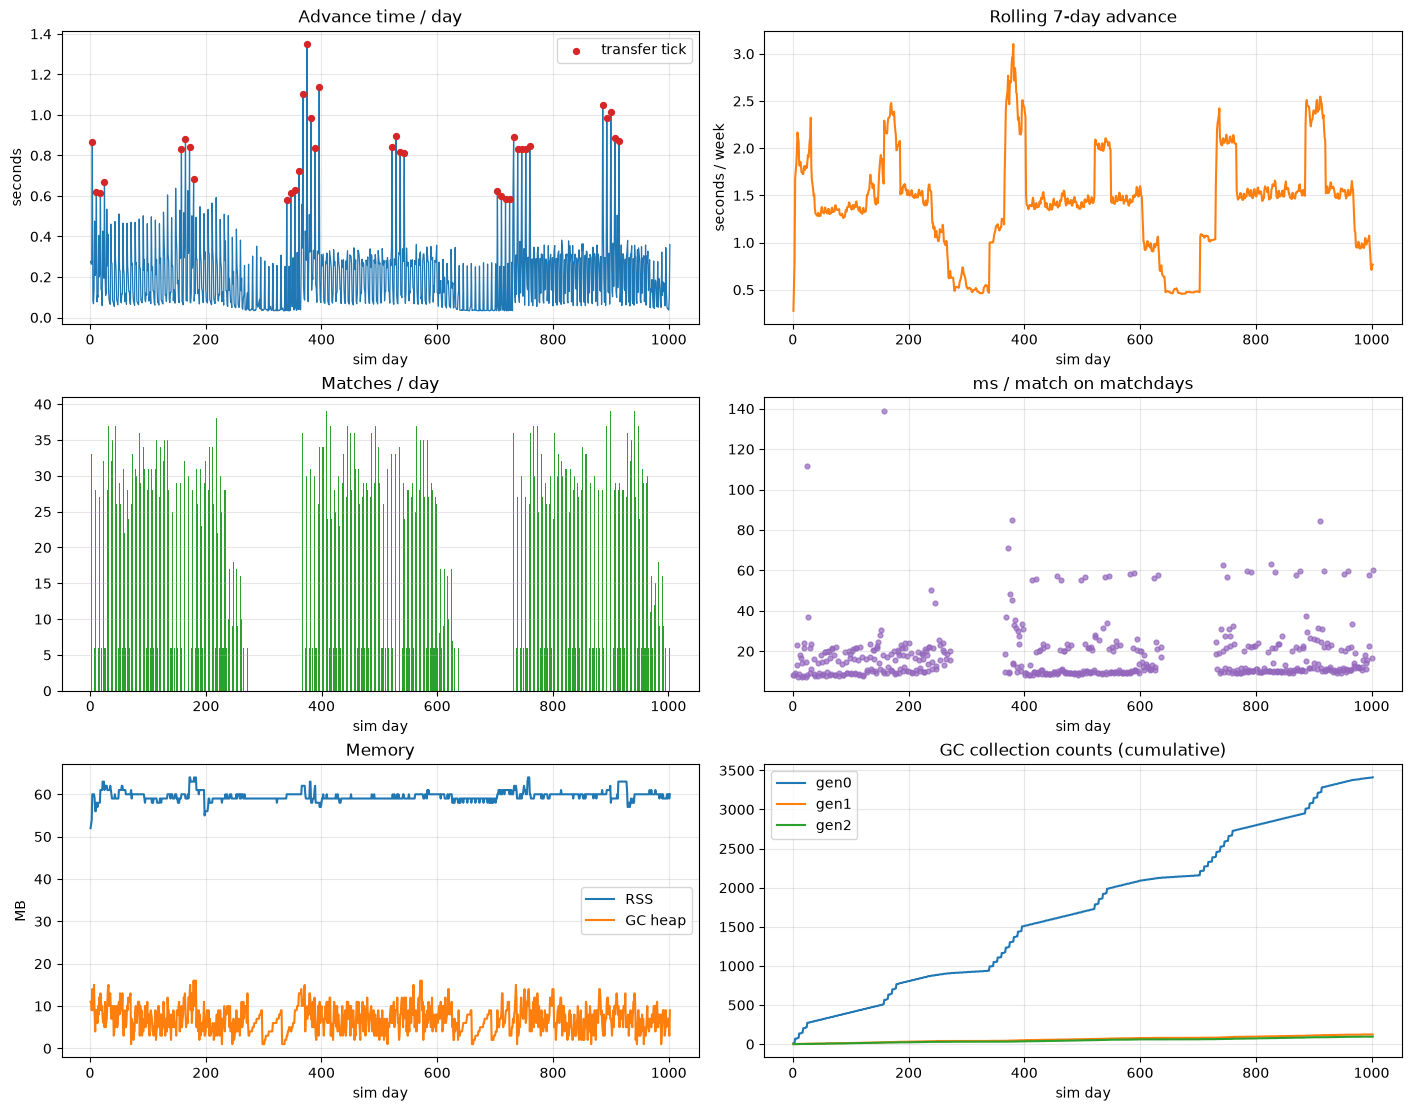

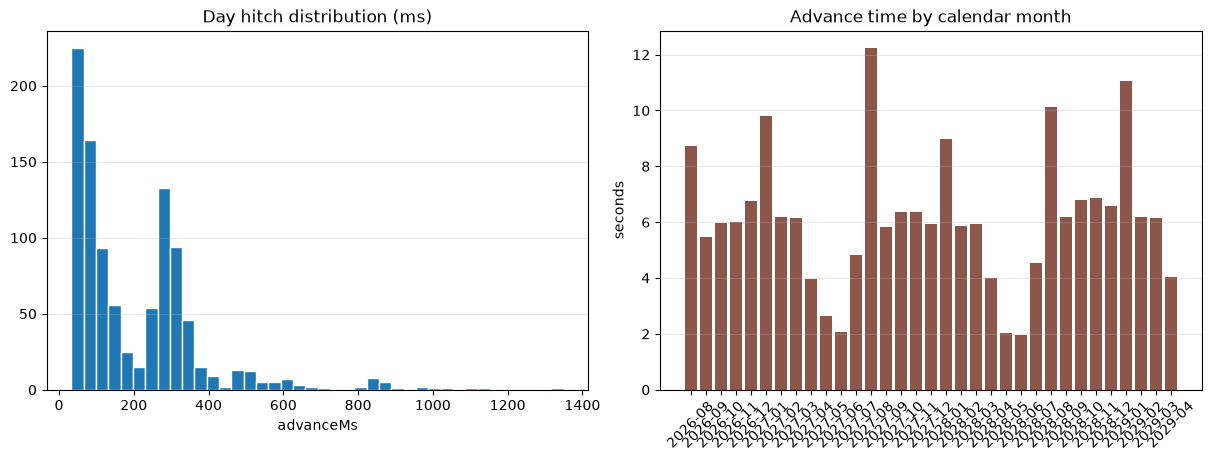

In [13]:
if csv_path.is_file():
    profile = load_profile(csv_path)
    print_profile(profile)
    plot_profile(profile, out_dir, show_plots=True)
else:
    print(f"No CSV at {csv_path}")

In [14]:
if db.is_file():
    con = sqlite3.connect(db.as_uri() + "?mode=ro", uri=True)
    try:
        dump_world(con)
    finally:
        con.close()
else:
    print(f"No DB at {db}")


World
Seed:          2026
Schema:        3
Current day:   740339  (2029-04-30)


,league,clubs,prize,start_mo,end_mo
0,Belgian Pro League,18,600000,8,5
1,Bundesliga,18,3000000,8,5
2,Championship,24,500000,8,5
3,Eredivisie,18,900000,8,5
4,La Liga,20,4000000,8,5
5,Ligue 1,18,2500000,8,5
6,Premier League,20,5000000,8,5
7,Primeira Liga,18,1200000,8,5
8,Serie A,20,3500000,8,5
9,Süper Lig,18,800000,8,5


,leagues,clubs,players,free_players,coaches,free_coaches,fixtures,played,finished_seasons
0,10,192,4304,65,216,24,10584,10584,30



Availability


,status,n,injured_days,suspended
0,Available,4277,0,0
1,Injured,14,14,0
2,Suspended,13,0,13


...

,club,league,cash,DailyIncome,WageBudget,Morale,Form,FanSupport,squad,wages
0,Real Madrid,La Liga,18422915,12000,10000,100,100,95,19,8474
1,Manchester City,Premier League,16057999,12000,10000,100,100,82,19,8482
2,Inter Milan,Serie A,15625287,12000,10000,95,95,95,19,6896
3,Paris Saint-Germain,Ligue 1,14361567,12000,10000,100,100,68,19,7642
4,Bayern Munich,Bundesliga,11946361,12000,10000,100,100,95,19,8224
5,AC Milan,Serie A,11560085,12000,10000,100,100,95,19,6394
6,Liverpool,Premier League,11184450,12000,10000,100,100,83,19,8036
7,Fenerbahçe,Süper Lig,11096739,12000,10000,100,100,68,19,5257
8,Benfica,Primeira Liga,11072399,12000,10000,100,100,90,19,5807
9,Erzurumspor,Süper Lig,10074271,12000,10000,35,35,37,24,3875



World history by type


,Type,n,amount
0,development,62570,17612
1,renewal,8094,1691750
2,coach-transfer,6710,297708885
3,player-transfer,6291,2256654848
4,release,3342,0



Recent market events


,Day,Type,person,from,to,Amount
0,740250,player-transfer,Sevilla Player 3,Samsunspor,Trabzonspor,415030
1,740250,coach-transfer,Coach Valencia,NaN,Trabzonspor,0
2,740250,player-transfer,Real Sociedad Player 14,Rizespor,Samsunspor,154154
3,740250,coach-transfer,Coach Middlesbrough,NaN,Samsunspor,0
4,740250,player-transfer,Osasuna Player 7,Çorum,Rizespor,367598
5,740250,coach-transfer,Coach Werder Bremen,NaN,Rizespor,0
6,740250,player-transfer,Celta Vigo Player 16,Konyaspor,Çorum,415030
7,740250,coach-transfer,Coach SC Paderborn,NaN,Çorum,0
8,740250,player-transfer,Free Agent Player 11,Kasımpaşa,Konyaspor,415030
9,740250,coach-transfer,Coach Bayer Leverkusen,NaN,Konyaspor,0
